<a href="https://colab.research.google.com/github/VadimBobrovnikov/Netology-Final-Work/blob/main/%D0%98%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('https://u.netology.ru/backend/uploads/lms/content_assets/file/11897/HR.csv?_gl=1*9f6i2p*_gcl_au*MTI1NDgyMTQ5OS4xNzY4MTU4Mjkx')
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Рассчитаем основные статистики для переменных

In [ ]:
def stat_numeric(row):
  return row.describe(exclude=[object])

def stat_cat(row):
  return row.describe(exclude=[np.number])



Медиана = 2 квратилю (50%)

In [ ]:
stat_numeric(df)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Мода = top, частота моды = freq, количество уникальных значений = 3.

In [ ]:
stat_cat(df)

,department,salary
count,14999,14999
unique,10,3
top,sales,low
freq,4140,7316


In [ ]:
df['department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [ ]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

work_accident, left, promotion_last_5years - являются бинарными признаками, для них тоже есть смысл найти уникальные значения и моду.

In [ ]:
print('Уникальные значения Work_accident:', df['Work_accident'].unique(),'мода:', df['Work_accident'].mode()[0])
print('Уникальные значения left:',df['left'].unique(), 'мода:', df['left'].mode()[0])
print('Уникальные значения promotion_last_5years:',df['promotion_last_5years'].unique(), 'мода:', df['promotion_last_5years'].mode()[0])

Уникальные значения Work_accident: [0 1] мода: 0
Уникальные значения left: [1 0] мода: 0
Уникальные значения promotion_last_5years: [0 1] мода: 0


Рассчитаем и визуализируем корреляционную матрицу.

In [ ]:
from scipy import stats

for col in df.select_dtypes(include=[np.number]).columns:
  p, stat = stats.shapiro(col)
  if p < 0.05:
    print('Распределение статистически отличается от нормального')
  else:
    print('Распределение статистически не отличается от нормального')

Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального
Распределение статистически не отличается от нормального


/tmp/ipython-input-1216951936.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p, stat = stats.shapiro(col)


Все признаки распределены нормально, значит можно использовать коэффициент Пирсона.

In [ ]:
corr_matrix = df.corr(method='pearson',numeric_only=True)
corr_matrix

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


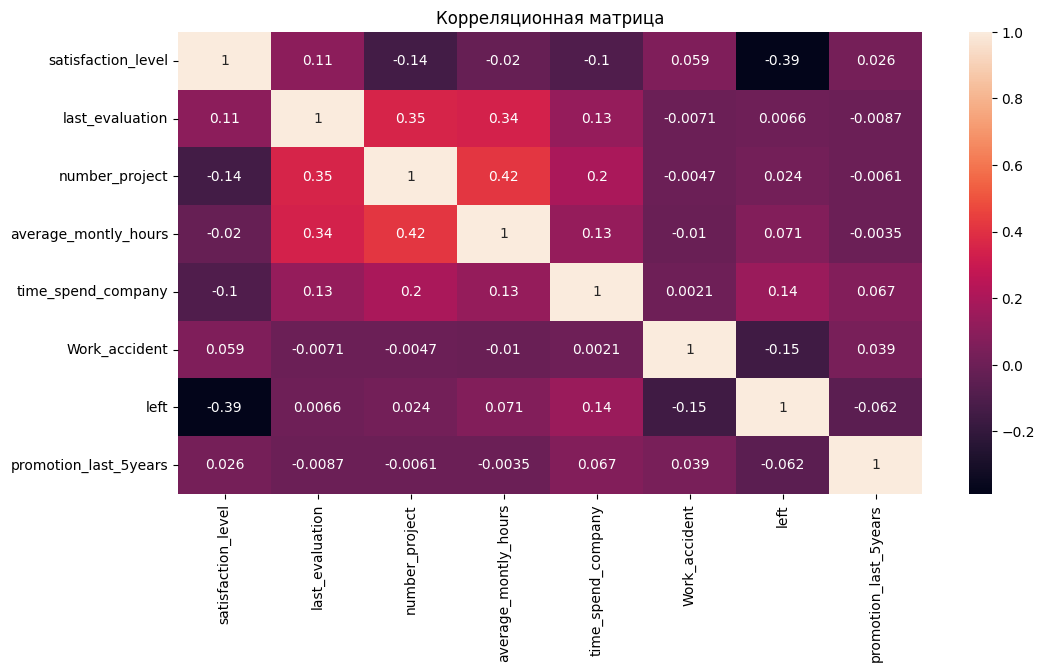

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Корреляционная матрица')
sns.heatmap(corr_matrix, annot=True)
plt.show()

Две самые скоррелированные (отрицательно) переменные - left и satisfaction_level. Две самые нескоррелированные - work_accident и time_spend_company.

Рассчитаем сколько сотрудников работает в каждом департаменте.

In [ ]:
df.groupby('department').size()

,0
department,
IT,1227
RandD,787
accounting,767
hr,739
management,630
marketing,858
product_mng,902
sales,4140
support,2229


Покажем распределение сотрудников по зарплате.

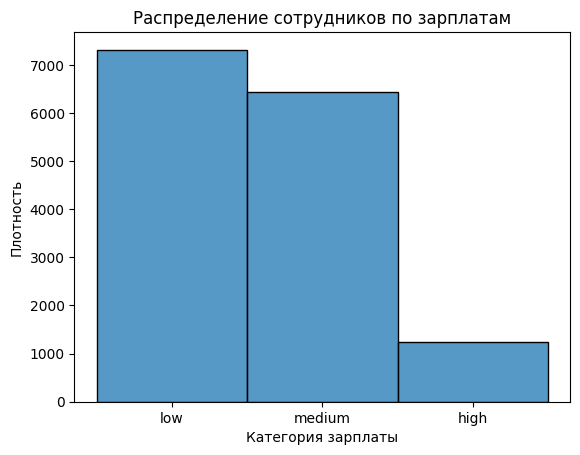

In [ ]:
plt.title('Распределение сотрудников по зарплатам')
sns.histplot(df['salary'])
plt.xlabel('Категория зарплаты')
plt.ylabel('Плотность')
plt.show()

Посмотрим распределение сотрудников по зарплатам в каждом департаменте по отдельности

In [ ]:
df_depart = df.groupby(['department','salary']).size().reset_index(name='count')

In [ ]:
df_depart

,department,salary,count
0,IT,high,83
1,IT,low,609
2,IT,medium,535
3,RandD,high,51
4,RandD,low,364
5,RandD,medium,372
6,accounting,high,74
7,accounting,low,358
8,accounting,medium,335
9,hr,high,45


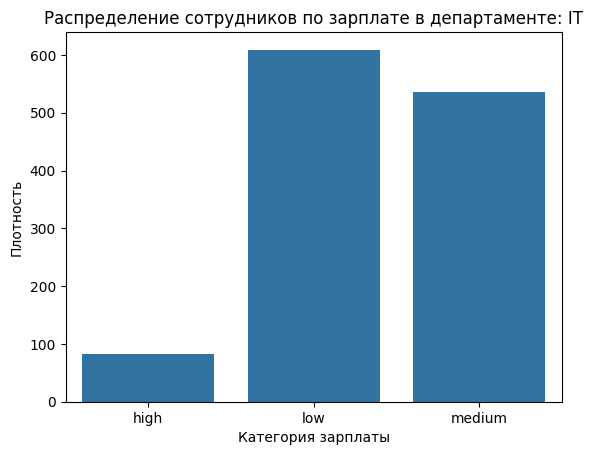

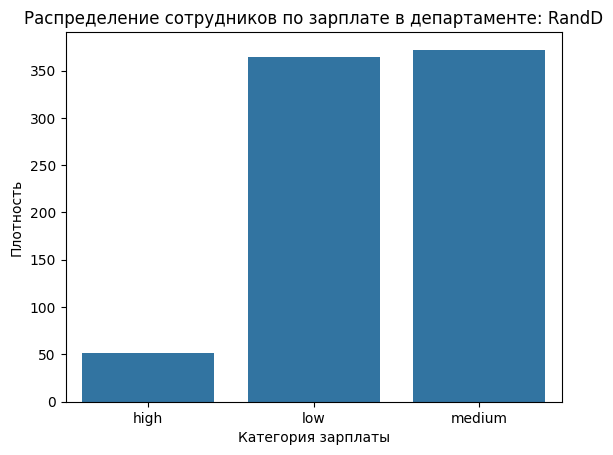

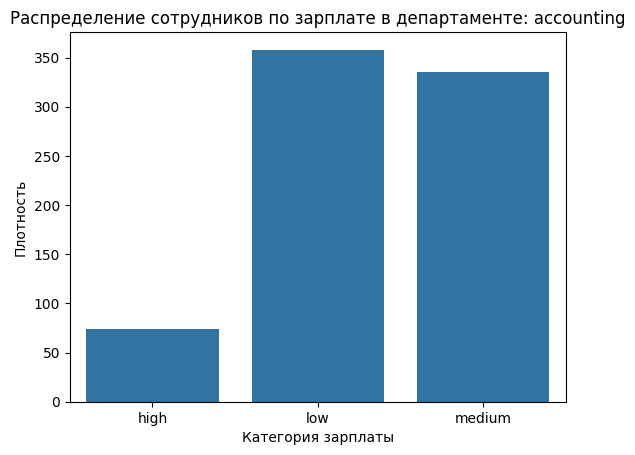

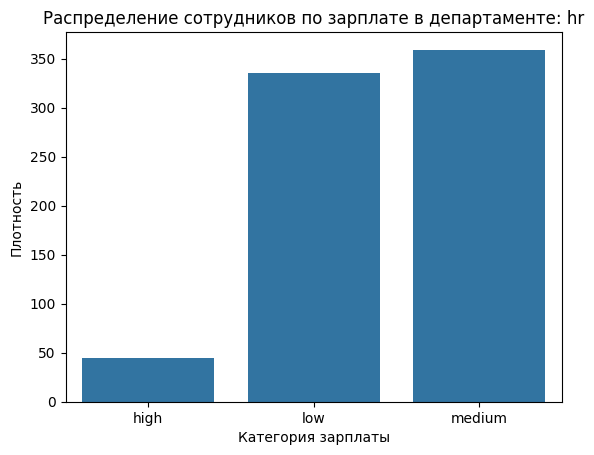

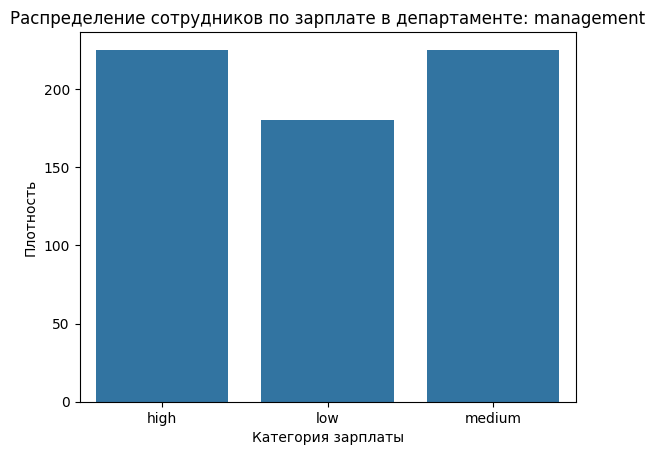

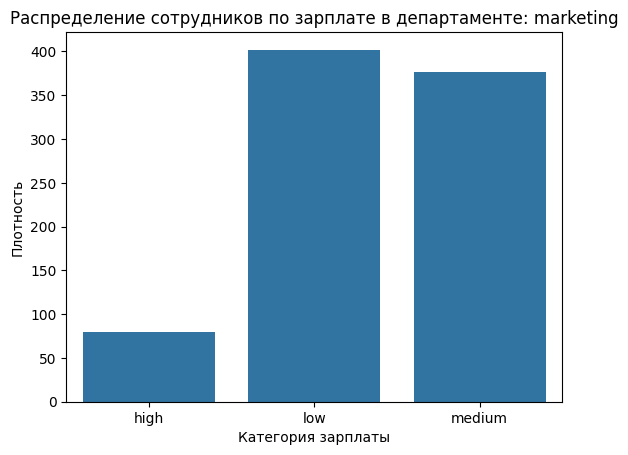

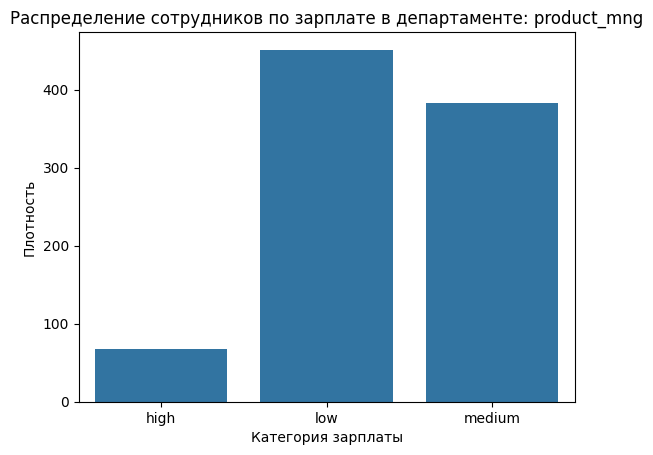

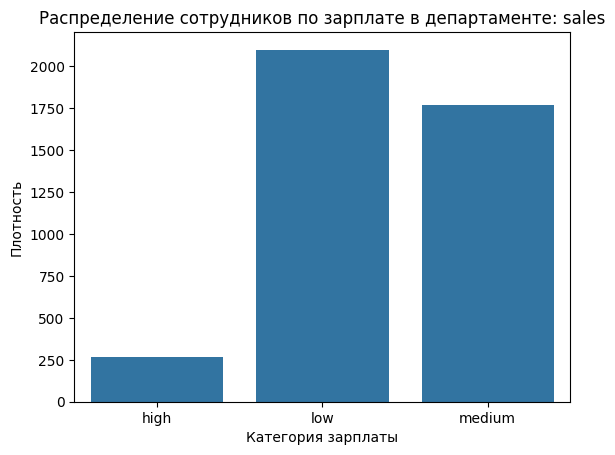

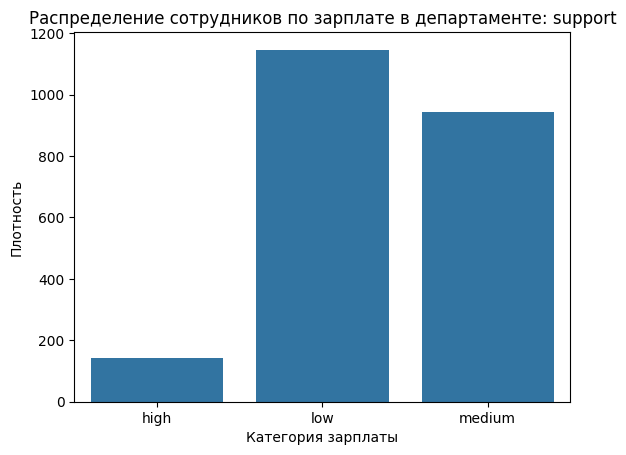

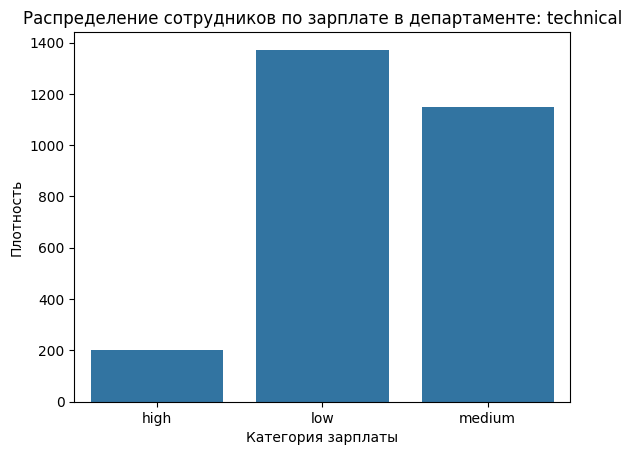

In [ ]:
for el in df_depart['department'].unique():
  depart = df_depart[df_depart['department']==el]
  plt.title(f'Распределение сотрудников по зарплате в департаменте: {el}')
  sns.barplot(x=depart['salary'],y=depart['count'])
  plt.xlabel('Категория зарплаты')
  plt.ylabel('Плотность')
  plt.show()

Проверим гипотезу о том, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом.

In [ ]:
high_payment = df[df['salary'] == 'high']
high_payment

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
72,0.45,0.49,2,149,3,0,1,0,product_mng,high
111,0.09,0.85,6,289,4,0,1,0,hr,high
189,0.44,0.51,2,156,3,0,1,0,technical,high
267,0.45,0.53,2,129,3,0,1,0,technical,high
306,0.37,0.46,2,149,3,0,1,0,marketing,high
...,...,...,...,...,...,...,...,...,...,...
14829,0.45,0.57,2,148,3,0,1,0,marketing,high
14868,0.43,0.55,2,130,3,0,1,0,support,high
14902,0.45,0.46,2,159,3,0,1,0,hr,high
14941,0.43,0.49,2,131,3,0,1,0,RandD,high


In [ ]:
low_payment = df[df['salary'] == 'low']
low_payment

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


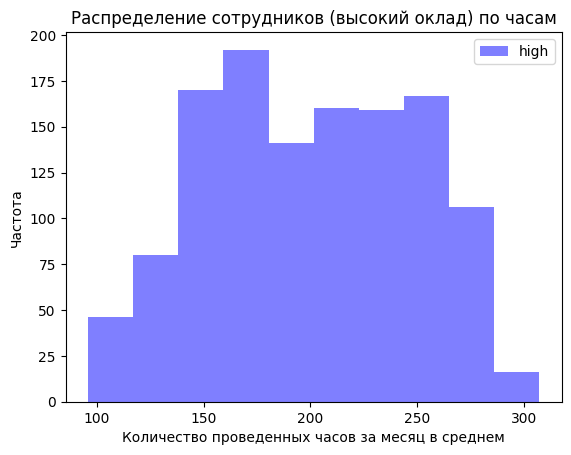

In [ ]:
plt.title('Распределение сотрудников (высокий оклад) по часам')
plt.hist(high_payment['average_montly_hours'],alpha=0.5,label='high', color='blue')
plt.xlabel('Количество проведенных часов за месяц в среднем')
plt.ylabel('Частота')
plt.legend()
plt.show()

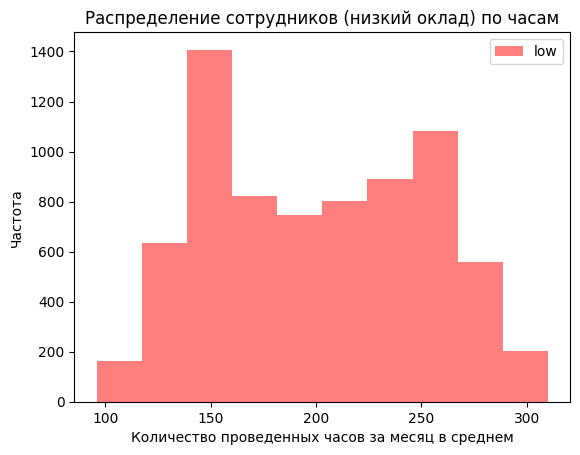

In [ ]:
plt.title('Распределение сотрудников (низкий оклад) по часам')
plt.hist(low_payment['average_montly_hours'],alpha=0.5,label='low', color='red')
plt.xlabel('Количество проведенных часов за месяц в среднем')
plt.ylabel('Частота')
plt.legend()
plt.show()

Как видно по графикам, у обеих выборок диапазон значений от 100 до 300 часов; они имеют похожее распределение с пиками в значениях 150 и 250; у выборки сотрудников с низким окладом проседание частот в районе от 150 до 250 часов сильнее выражено чем у выборки сотрудников с высоким окладом, возможно дело в большем количестве значений.

In [ ]:
print(f'Статистики для сотрудников с высокой зарплатой: {high_payment['average_montly_hours'].describe()}')

Статистики для сотрудников с высокой зарплатой: count    1237.000000
mean      199.867421
std        47.710446
min        96.000000
25%       161.000000
50%       199.000000
75%       241.000000
max       307.000000
Name: average_montly_hours, dtype: float64


In [ ]:
print(f'Статистики для сотрудников с высокой зарплатой: {low_payment['average_montly_hours'].describe()}')

Статистики для сотрудников с высокой зарплатой: count    7316.000000
mean      200.996583
std        50.832214
min        96.000000
25%       155.000000
50%       199.000000
75%       246.000000
max       310.000000
Name: average_montly_hours, dtype: float64


Как можно увидеть статистика количества часов проведенных на работе у сотрудников с высокой и низкой зарплатой практически одинакова.

In [ ]:
stat, p = stats.shapiro(high_payment['average_montly_hours'])

if p < 0.05:
  print("Данные скорее всего распределены не нормально")
else:
  print("Данные скорее всего распределены нормально")

Данные скорее всего распределены не нормально


In [ ]:
stat, p = stats.shapiro(low_payment['average_montly_hours'])

if p < 0.05:
  print("Данные скорее всего распределены не нормально")
else:
  print("Данные скорее всего распределены нормально")

Данные скорее всего распределены не нормально


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7316.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
stat, p = stats.levene(high_payment['average_montly_hours'], low_payment['average_montly_hours'])

if p > 0.05:
  print('Вариации статистически не отличаются')
else:
  print('Вариации статистически различаются')

Вариации статистически различаются


Так как дисперсия у выборок различна, вместо Манна-Уитни лучше использовать тест Бруннера-Мунзеля

In [ ]:
stat, p = stats.brunnermunzel(high_payment['average_montly_hours'],low_payment['average_montly_hours'])

if p > 0.05:
  print('Разница количества часов статистически не значима')
else:
  print('Разница количества часов статистически значима')

Разница количества часов статистически не значима


С учетом результатов визуализации, расчета статистик и проверки с помошью теста Бруннера-Мунзеля, можно сказать, что сотрудники с высоким окладом не проводят на работе больше времени чем сотрудники с низким окладом.

Рассчитаем слудющие показатели среди уволившихся и не уволившихся сотрудников (по отдельности): 1. Доля сотрудников с повышением за последние 5 лет 2. Средняя степень удовлетворенности 3.Среднее количество проектов

In [ ]:
left = df[df['left']== 1]
left

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
not_left = df[df['left']== 0]
not_left

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
2000,0.58,0.74,4,215,3,0,0,0,sales,low
2001,0.82,0.67,2,202,3,0,0,0,sales,low
2002,0.45,0.69,5,193,3,0,0,0,sales,low
2003,0.78,0.82,5,247,3,0,0,0,sales,low
2004,0.49,0.60,3,214,2,0,0,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14206,0.90,0.55,3,259,10,1,0,1,management,high
14207,0.74,0.95,5,266,10,0,0,1,management,high
14208,0.85,0.54,3,185,10,0,0,1,management,high
14209,0.33,0.65,3,172,10,0,0,1,marketing,high


In [ ]:
def stat_for_left_not_left(row):
  promote = row[row['promotion_last_5years']==1]['promotion_last_5years'].count()
  total = row['promotion_last_5years'].count()

  procent_promotion = (promote/total) * 100
  mean_satisfaction_level = row['satisfaction_level'].mean()
  mean_number_of_projects = row['number_project'].mean()

  print(f'Доля повышений: {procent_promotion}%, \nСредний уровень удовлетворенности: {mean_satisfaction_level}, \nСреднее количество проектов: {mean_number_of_projects}')

In [ ]:
stat_for_left_not_left(left)

Доля повышений: 0.5320638476617194%, 
Средний уровень удовлетворенности: 0.4400980117614114, 
Среднее количество проектов: 3.8555026603192384


In [ ]:
stat_for_left_not_left(not_left)

Доля повышений: 2.6251312565628284%, 
Средний уровень удовлетворенности: 0.666809590479524, 
Среднее количество проектов: 3.786664333216661


Как можно заметить, у уволившихся сотрудников в среднем был заметно меньший уровень удовлетворенности и доля повышений за 5 лет составляла 0.5%, у не уволившихся сотрудников был больший средний уровень удовлетворенности и доля повышений составляла 2.6%, среднее число проектов не сильно отличается, у обеих групп примерно 3.8 проектов в среднем.

Разделим данные на тестовую и обучающую выборки. Построем модель LDA, предсказывающую уволился ли сотрудник на основе имеющихся факторов (кроме department и salary). Оценим качество модели на тестовой выборке

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split


X = df.drop(['department', 'salary', 'left'],axis=1)
y= df['left'].values

print(X, y)

       satisfaction_level  last_evaluation  number_project  \
0                    0.38             0.53               2   
1                    0.80             0.86               5   
2                    0.11             0.88               7   
3                    0.72             0.87               5   
4                    0.37             0.52               2   
...                   ...              ...             ...   
14994                0.40             0.57               2   
14995                0.37             0.48               2   
14996                0.37             0.53               2   
14997                0.11             0.96               6   
14998                0.37             0.52               2   

       average_montly_hours  time_spend_company  Work_accident  \
0                       157                   3              0   
1                       262                   6              0   
2                       272                   4          

In [ ]:
X

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
0,0.38,0.53,2,157,3,0,0
1,0.80,0.86,5,262,6,0,0
2,0.11,0.88,7,272,4,0,0
3,0.72,0.87,5,223,5,0,0
4,0.37,0.52,2,159,3,0,0
...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0
14995,0.37,0.48,2,160,3,0,0
14996,0.37,0.53,2,143,3,0,0
14997,0.11,0.96,6,280,4,0,0


Проверим дисбаланс классов

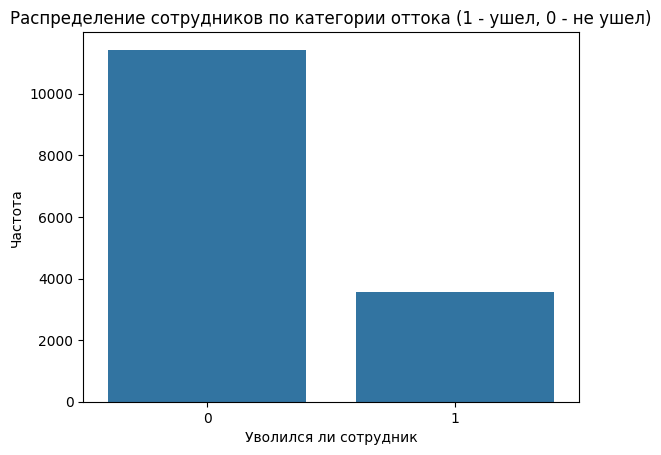

In [ ]:
plt.title('Распределение сотрудников по категории оттока (1 - ушел, 0 - не ушел)')
sns.countplot(x=df['left'], data=df)
plt.xlabel('Уволился ли сотрудник')
plt.ylabel('Частота')
plt.show()

Как видно по графику в целевой переменной присутствует большой дисбаланс классов.

In [ ]:
model = LinearDiscriminantAnalysis()

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(10499, 7) (4500, 7) (10499,) (4500,)


In [ ]:
y_train

array([0, 1, 1, ..., 1, 0, 1])

In [ ]:
model.fit(X_train, y_train)


LinearDiscriminantAnalysis()

In [ ]:
pred = model.predict(X_test)
pred

array([0, 1, 0, ..., 0, 0, 0])

Проведем оценку точности модели.

In [ ]:
model.score(X_test, y_test)

0.76

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=3, random_state=1)

scores = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1)
print(np.mean(scores))

0.3368103496028631


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85      3429
           1       0.49      0.26      0.34      1071

    accuracy                           0.76      4500
   macro avg       0.65      0.59      0.60      4500
weighted avg       0.73      0.76      0.73      4500



In [ ]:
res = pd.DataFrame({'actual': y_test, 'prediction':pred})
res

,actual,prediction
0,0,0
1,0,1
2,0,0
3,0,1
4,0,0
...,...,...
4495,0,0
4496,0,1
4497,0,0
4498,1,0


Как видно, модель показала хорошие результаты на тестовой выборке, но плохие на кросс-валидации, также на отчете классификации видны низкие показатели метрик для класса - 1. Скорее всего проблема в дисбалансе классов. Можно попробовать построить модели с данными, измененными с помощью сэмплирования.

Обучение модели с сэмплированием вниз.

In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print(X_train.shape, np.unique(y_train, return_counts = True))
print(X_train_under.shape, np.unique(y_train_under, return_counts = True))

(10499, 7) (array([0, 1]), array([7999, 2500]))
(5000, 7) (array([0, 1]), array([2500, 2500]))


In [ ]:
model.fit(X_train_under, y_train_under)

pred = model.predict(X_test)
model.score(X_test, y_test)

0.7451111111111111

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=3, random_state=1)

scores = cross_val_score(model, X_train_under, y_train_under, scoring='f1', cv=cv, n_jobs=-1)
print(np.mean(scores))

0.7464752252453888


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.90      0.74      0.82      3429
           1       0.48      0.75      0.58      1071

    accuracy                           0.75      4500
   macro avg       0.69      0.75      0.70      4500
weighted avg       0.80      0.75      0.76      4500



In [ ]:
res = pd.DataFrame({'actual': y_test, 'prediction':pred})
res

,actual,prediction
0,0,0
1,0,1
2,0,0
3,0,1
4,0,1
...,...,...
4495,0,0
4496,0,1
4497,0,0
4498,1,1


Обучение модели с сэмплированием вверх.

In [ ]:
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print(X_train.shape, np.unique(y_train, return_counts = True))
print(X_train_over.shape, np.unique(y_train_over, return_counts = True))

(10499, 7) (array([0, 1]), array([7999, 2500]))
(15998, 7) (array([0, 1]), array([7999, 7999]))


In [ ]:
model.fit(X_train_over, y_train_over)

pred = model.predict(X_test)
model.score(X_test, y_test)

0.7431111111111111

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=2, n_repeats=3, random_state=1)

scores = cross_val_score(model, X_train_over, y_train_over, scoring='f1', cv=cv, n_jobs=-1)
print(np.mean(scores))

0.7474866821760875


In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      3429
           1       0.47      0.75      0.58      1071

    accuracy                           0.74      4500
   macro avg       0.69      0.75      0.70      4500
weighted avg       0.80      0.74      0.76      4500



In [ ]:
res = pd.DataFrame({'actual': y_test, 'prediction':pred})
res

,actual,prediction
0,0,0
1,0,1
2,0,0
3,0,1
4,0,1
...,...,...
4495,0,0
4496,0,1
4497,0,0
4498,1,1


По результатам обе модели, если судить по мтерикам, справились почти одинаково. При этом показатели recall, f1 значительно улучшились, также как и результат на кросс-валидации.